Import Libraries

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    make_scorer
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

Load Dataset

In [6]:
df=pd.read_csv("water_potability.csv")

In [7]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [8]:
df.shape

(3276, 10)

In [9]:
df.columns.tolist()

['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity',
 'Potability']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


Check Missing Values



In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
Sulfate,781
ph,491
Trihalomethanes,162
Hardness,0
Chloramines,0
Solids,0
Conductivity,0
Organic_carbon,0
Turbidity,0
Potability,0


Check Duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

Statistical Description

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


In [14]:
df.corr()["Potability"].sort_values()

,Potability
Organic_carbon,-0.030001
Sulfate,-0.023577
Hardness,-0.013837
Conductivity,-0.008128
ph,-0.003556
Turbidity,0.001581
Trihalomethanes,0.007130
Chloramines,0.023779
Solids,0.033743
Potability,1.000000


Target Analysis

In [15]:
df["Potability"].value_counts(dropna=False)

,count
Potability,
0,1998
1,1278


In [16]:
df["Potability"].value_counts(normalize=True) * 100

,proportion
Potability,
0,60.989011
1,39.010989


In [17]:
display(df.groupby("Potability").mean().T)
display(df.groupby("Potability").median().T)

Potability,0,1
ph,7.085378,7.073783
Hardness,196.733292,195.800744
Solids,21777.490788,22383.991018
Chloramines,7.092175,7.169338
Sulfate,334.564290,332.566990
Conductivity,426.730454,425.383800
Organic_carbon,14.364335,14.160893
Trihalomethanes,66.303555,66.539684
Turbidity,3.965800,3.968328


Potability,0,1
ph,7.035456,7.036752
Hardness,197.123423,196.632907
Solids,20809.618280,21199.386614
Chloramines,7.090334,7.215163
Sulfate,333.389426,331.838167
Conductivity,422.229331,420.712729
Organic_carbon,14.293508,14.162809
Trihalomethanes,66.542198,66.678214
Turbidity,3.948076,3.958576


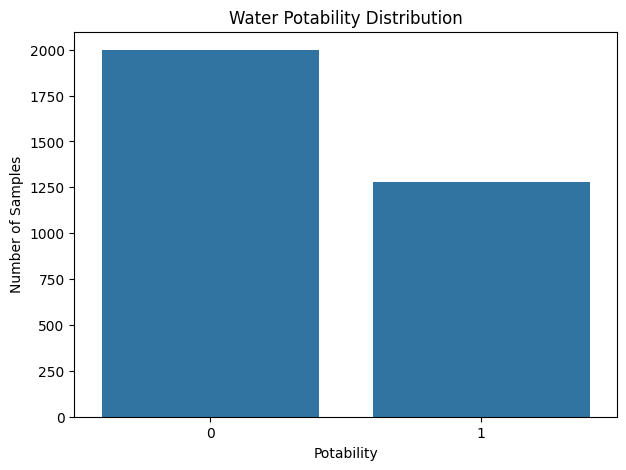

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Potability")

plt.title("Water Potability Distribution")
plt.xlabel("Potability")
plt.ylabel("Number of Samples")

plt.show()

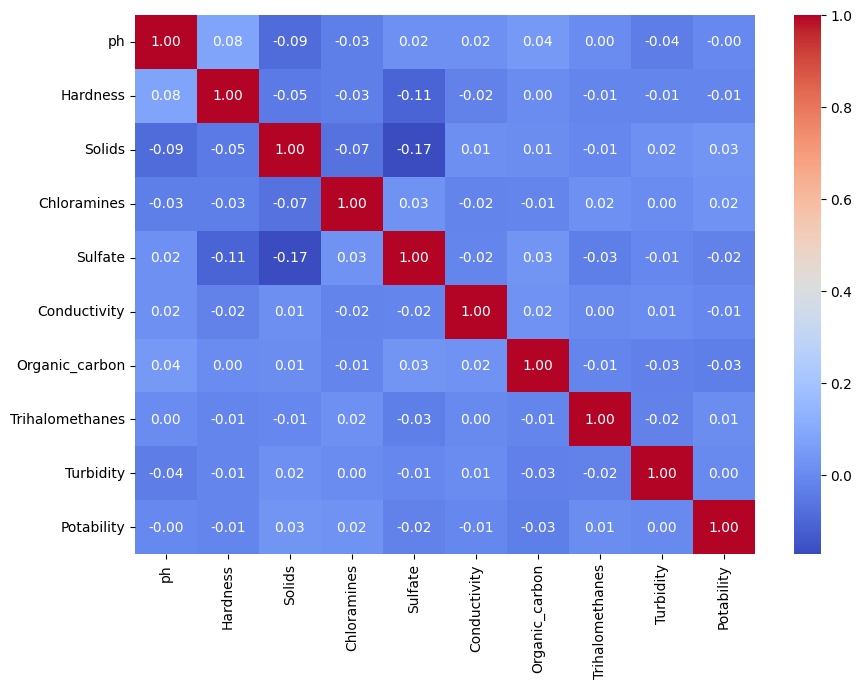

Organic_carbon    -0.030001
Sulfate           -0.023577
Hardness          -0.013837
Conductivity      -0.008128
ph                -0.003556
Turbidity          0.001581
Trihalomethanes    0.007130
Chloramines        0.023779
Solids             0.033743
Potability         1.000000
Name: Potability, dtype: float64


In [19]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()
print(df.corr()["Potability"].sort_values())

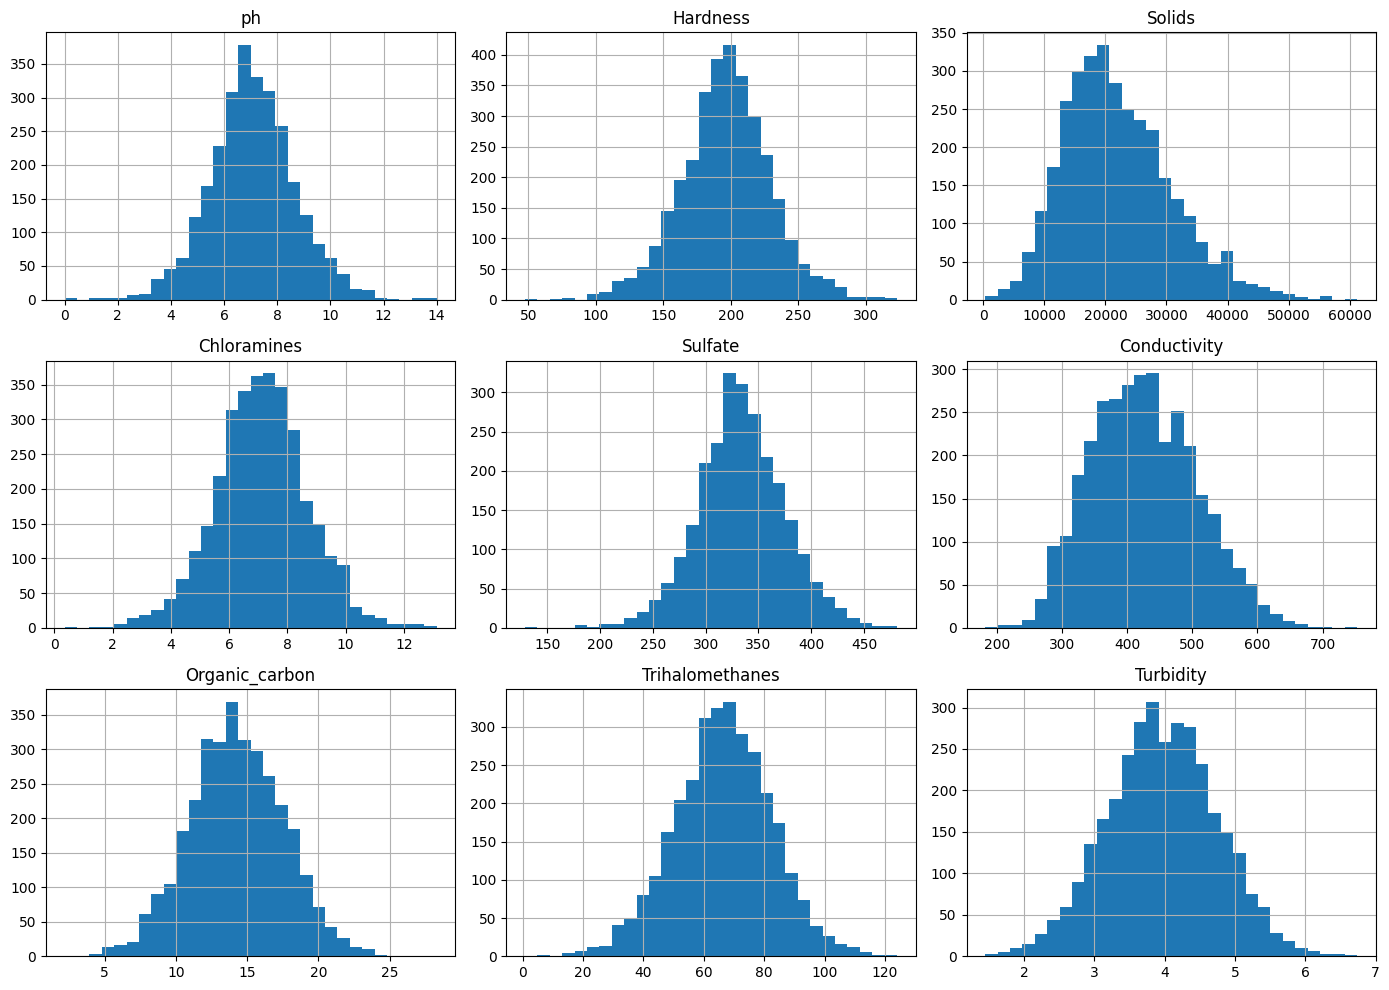

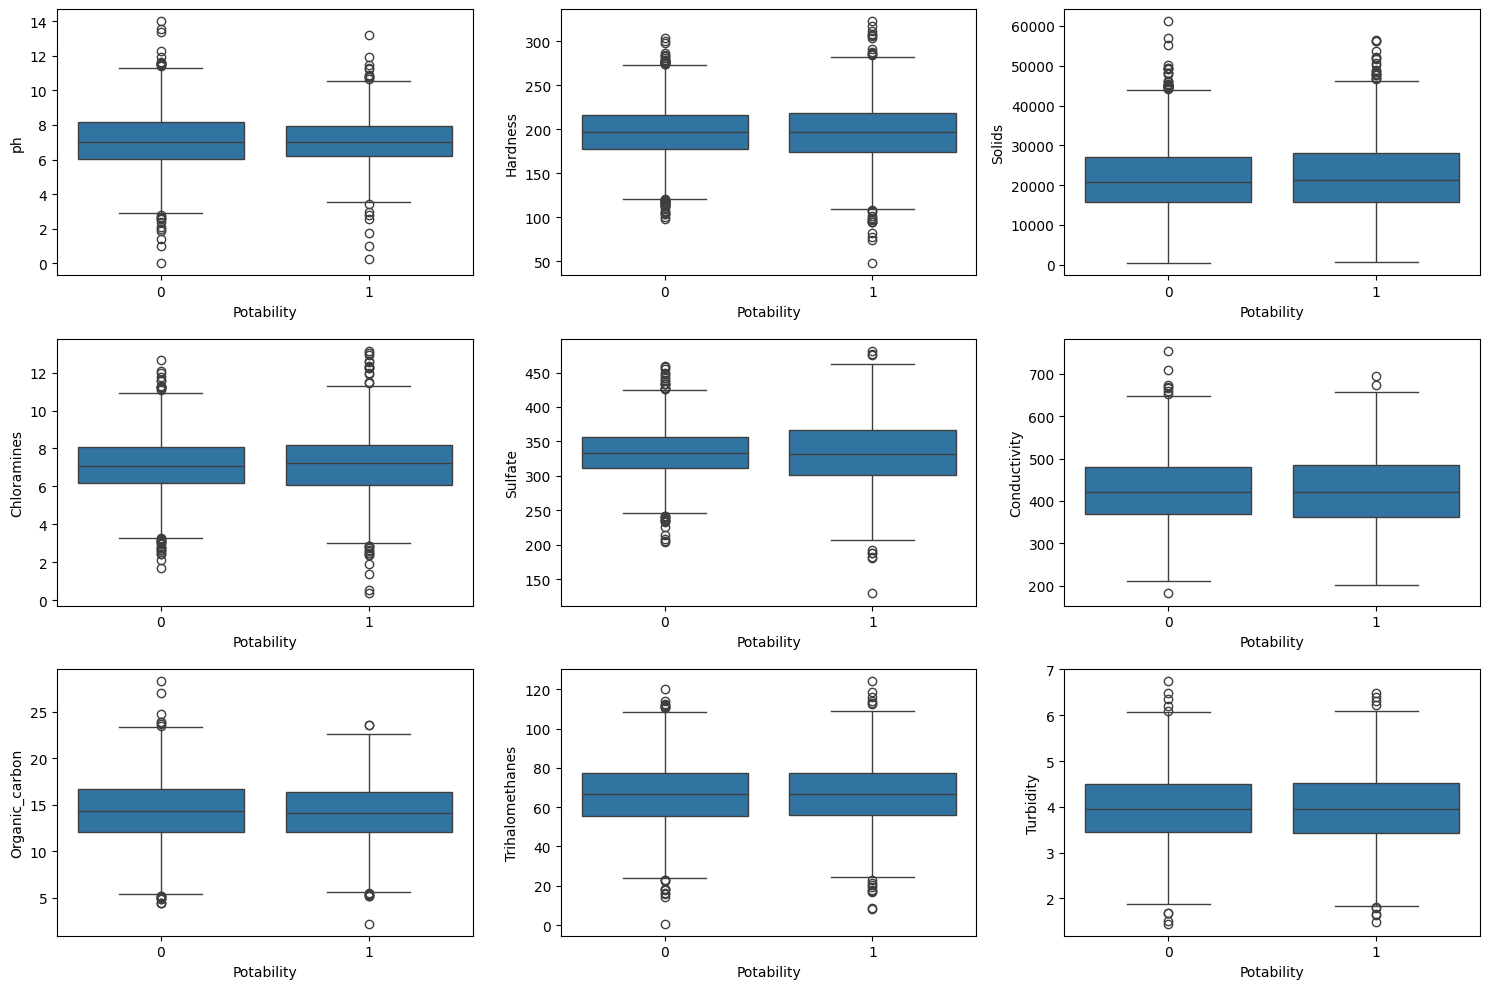

In [20]:
features = df.columns[:-1]


df[features].hist(bins=30, figsize=(14, 10)); plt.tight_layout(); plt.show()


fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, features):
    sns.boxplot(data=df, x="Potability", y=col, ax=ax)
plt.tight_layout(); plt.show()

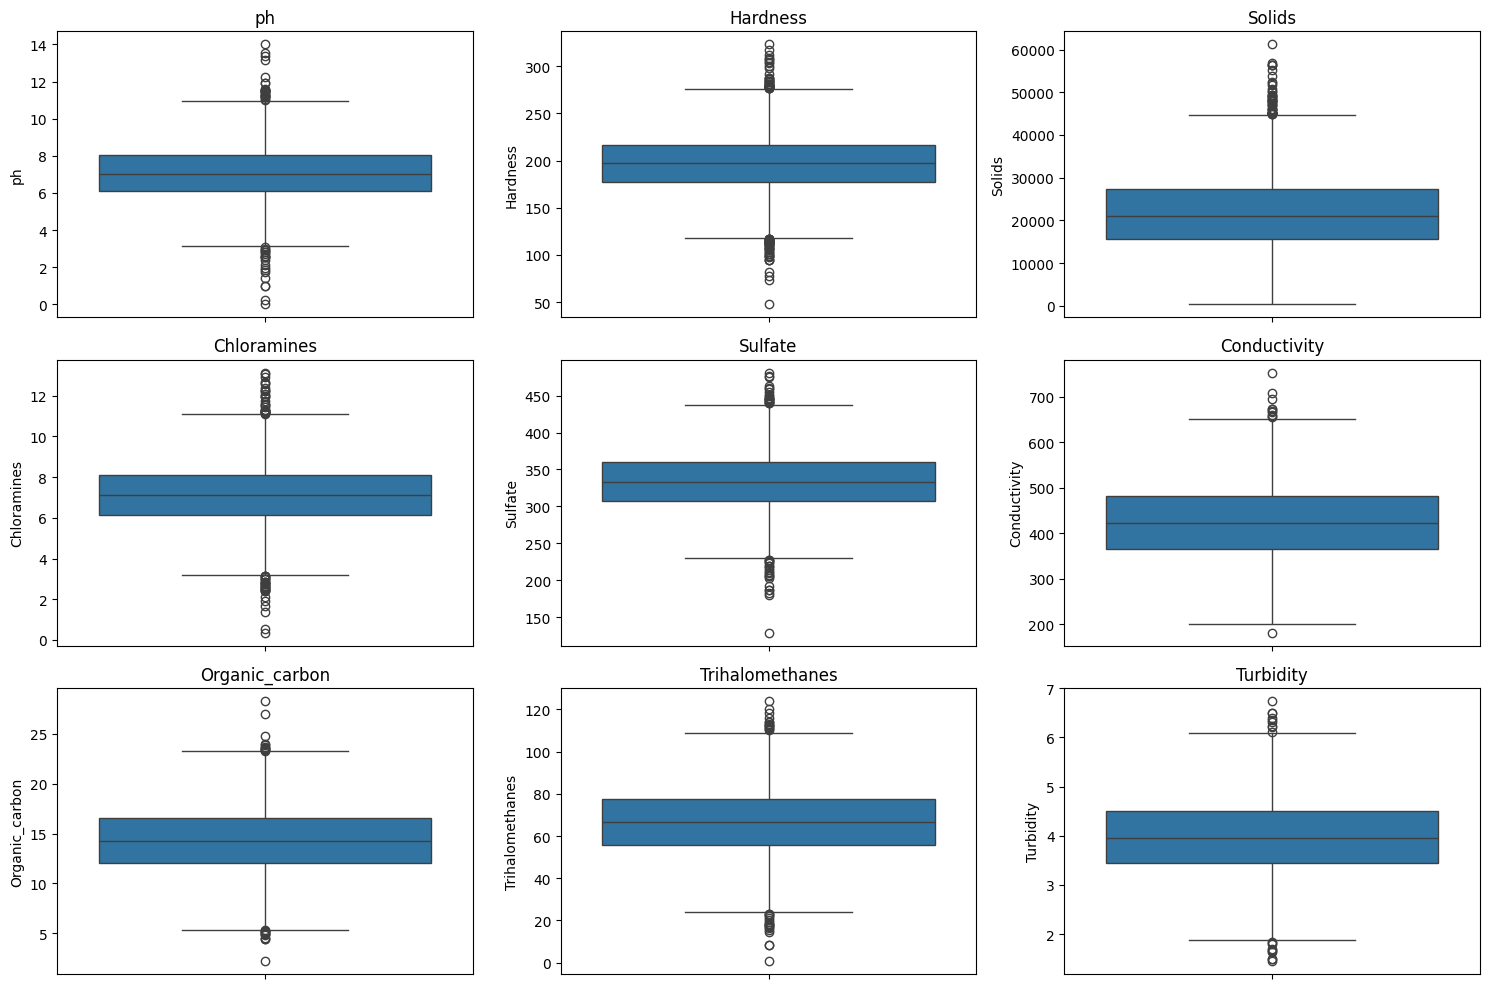

In [21]:
numeric_features = df.drop(columns=["Potability"]).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

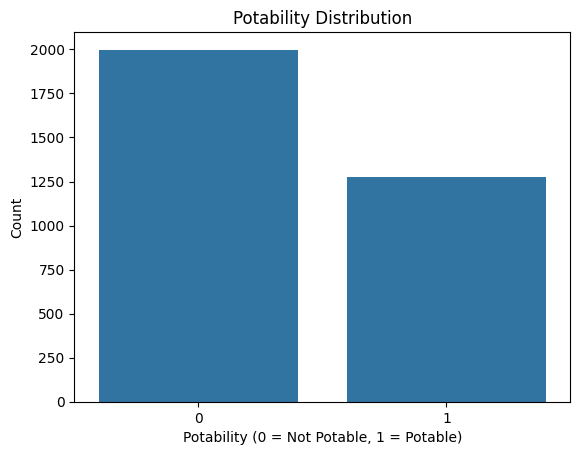

In [22]:

sns.countplot(data=df, x="Potability")

plt.title("Potability Distribution")
plt.xlabel("Potability (0 = Not Potable, 1 = Potable)")
plt.ylabel("Count")

plt.show()


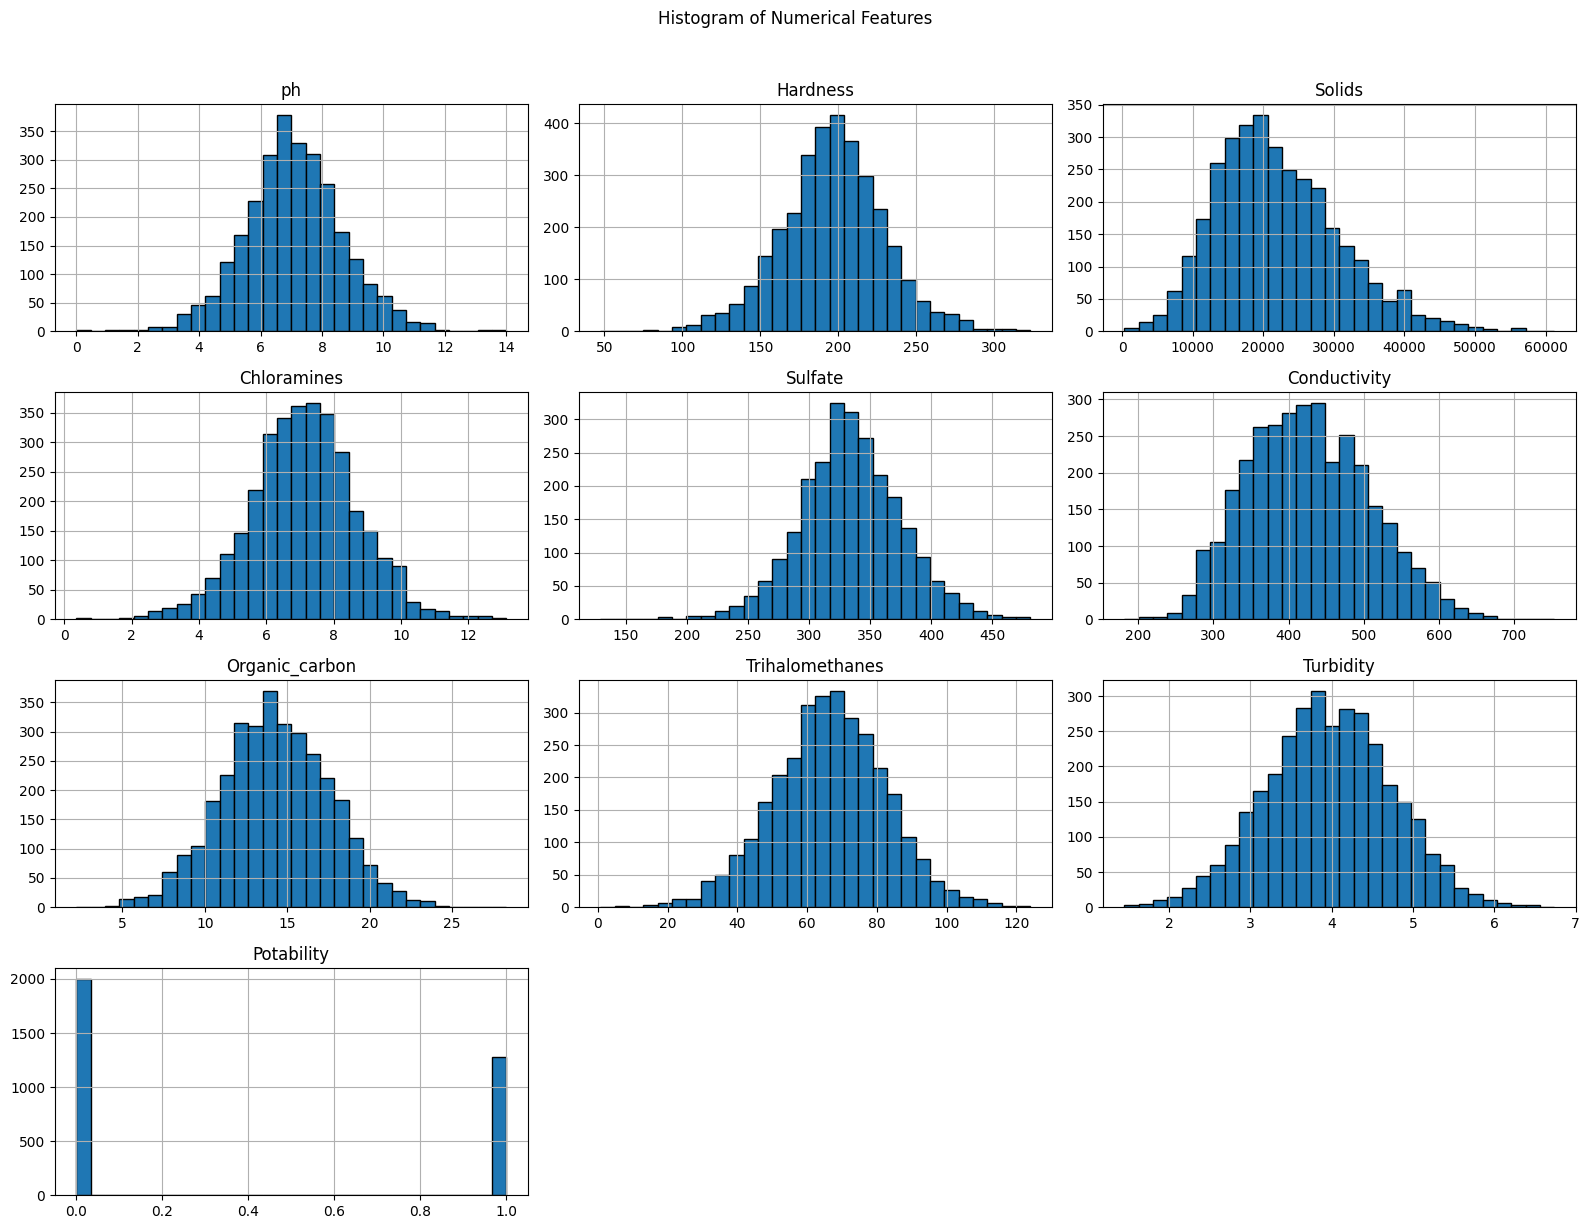

In [23]:

df.hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.suptitle("Histogram of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()


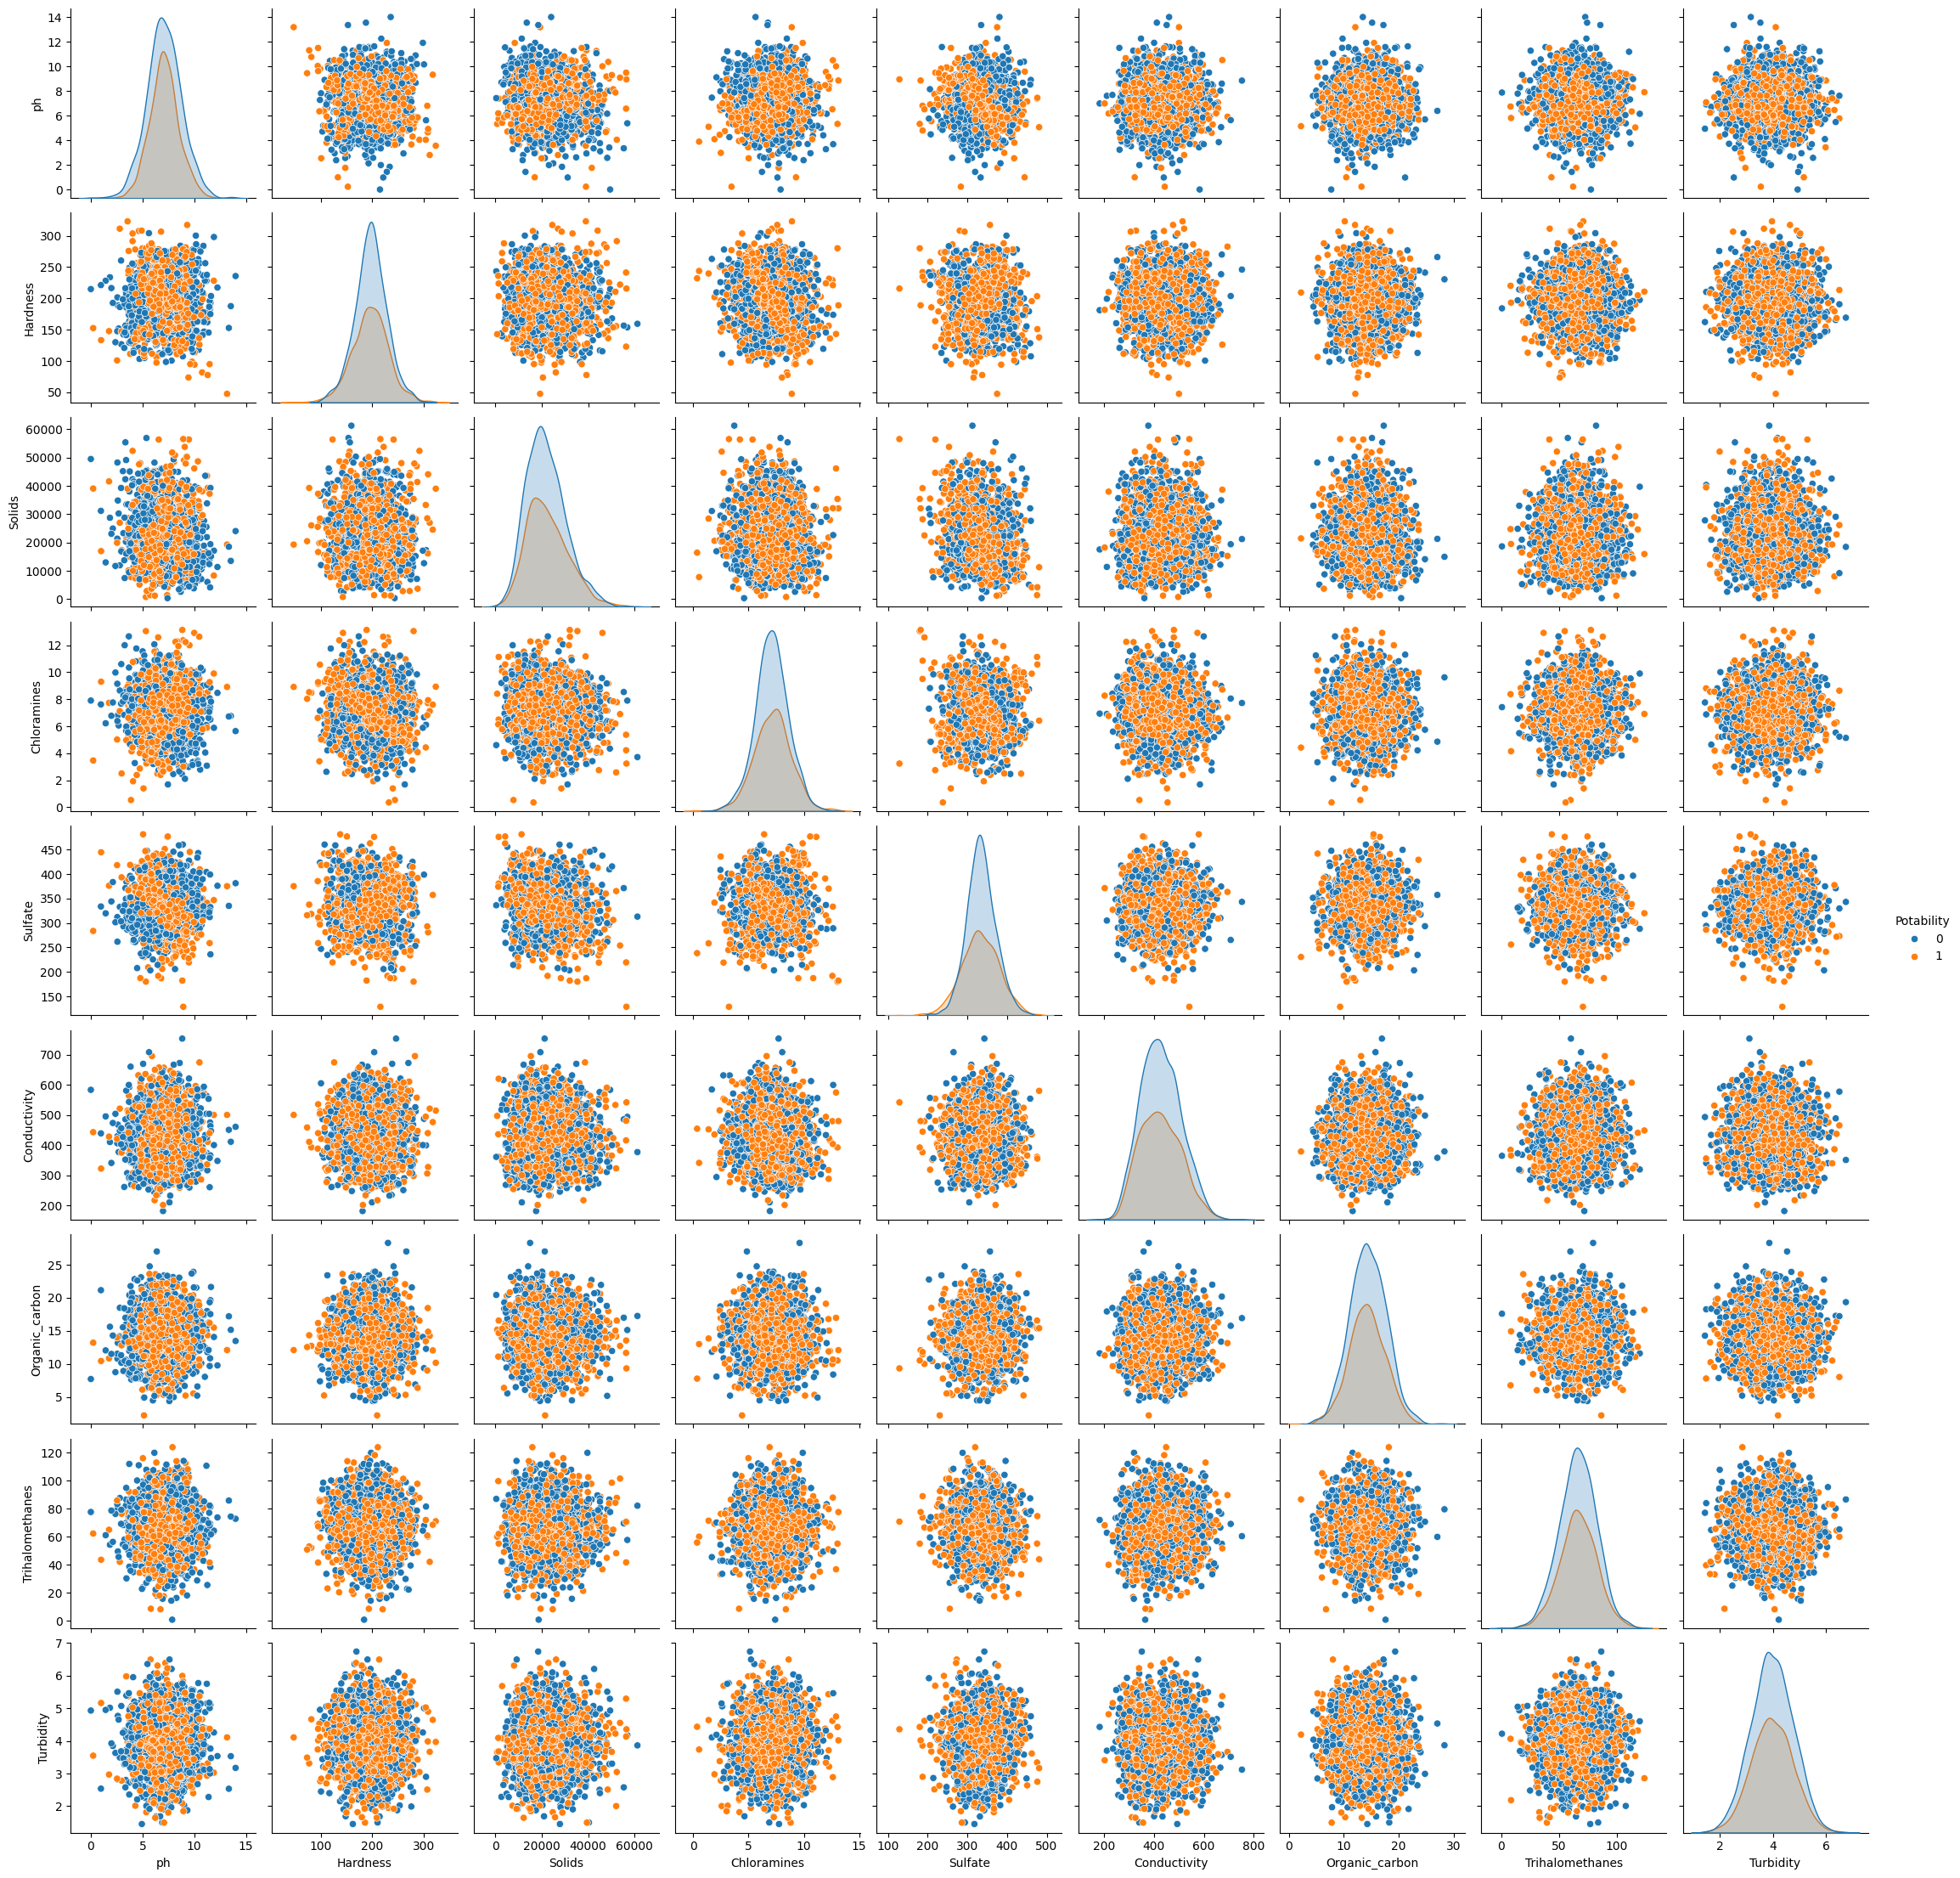

In [24]:
sns.pairplot(df, hue="Potability")
plt.show()


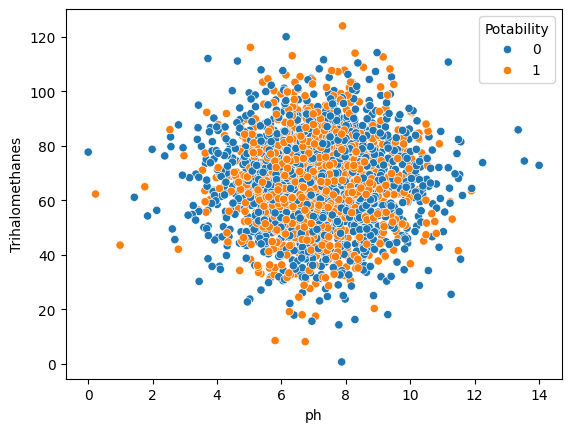

In [25]:
sns.scatterplot(data=df, x="ph", y="Trihalomethanes", hue="Potability")
plt.show()


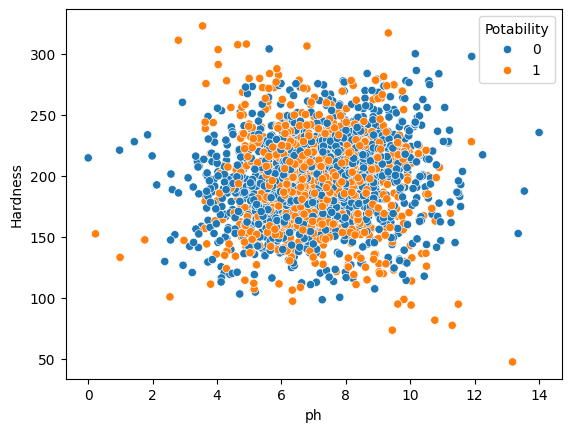

In [26]:
sns.scatterplot(data=df, x="ph", y="Hardness", hue="Potability")
plt.show()

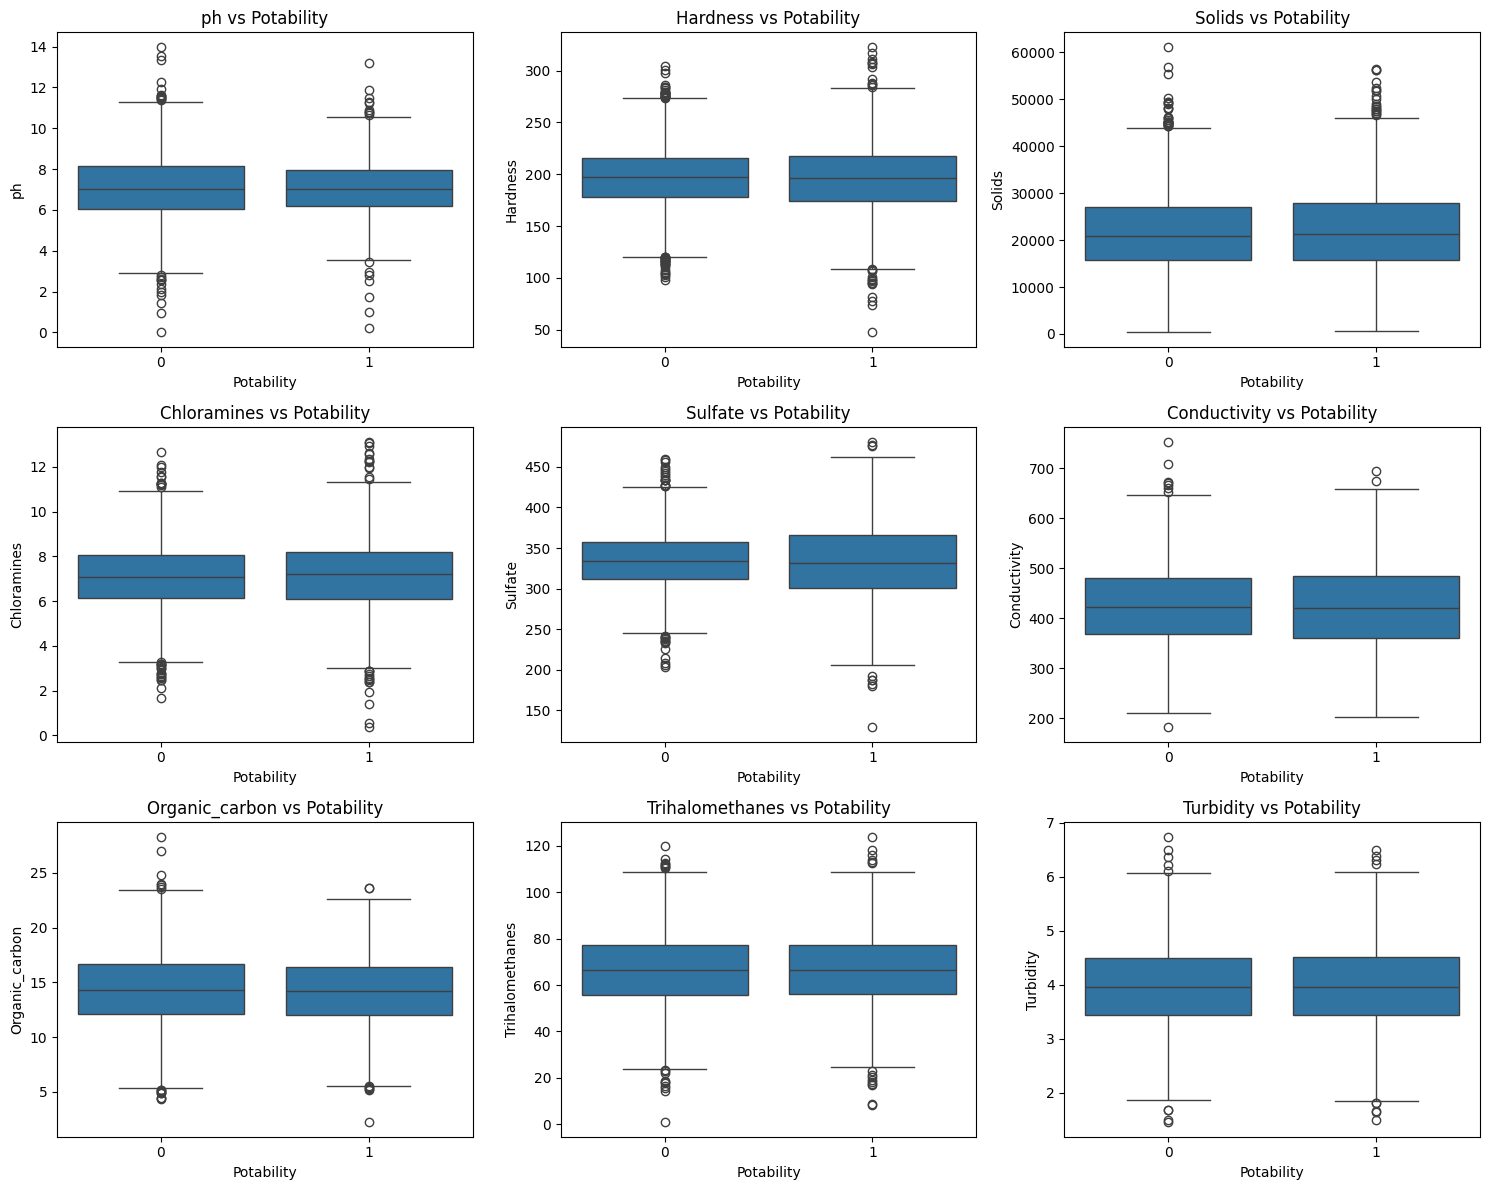

In [27]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)

    sns.boxplot(
        data=df,
        x="Potability",
        y=col
    )

    plt.title(f"{col} vs Potability")

plt.tight_layout()
plt.show()

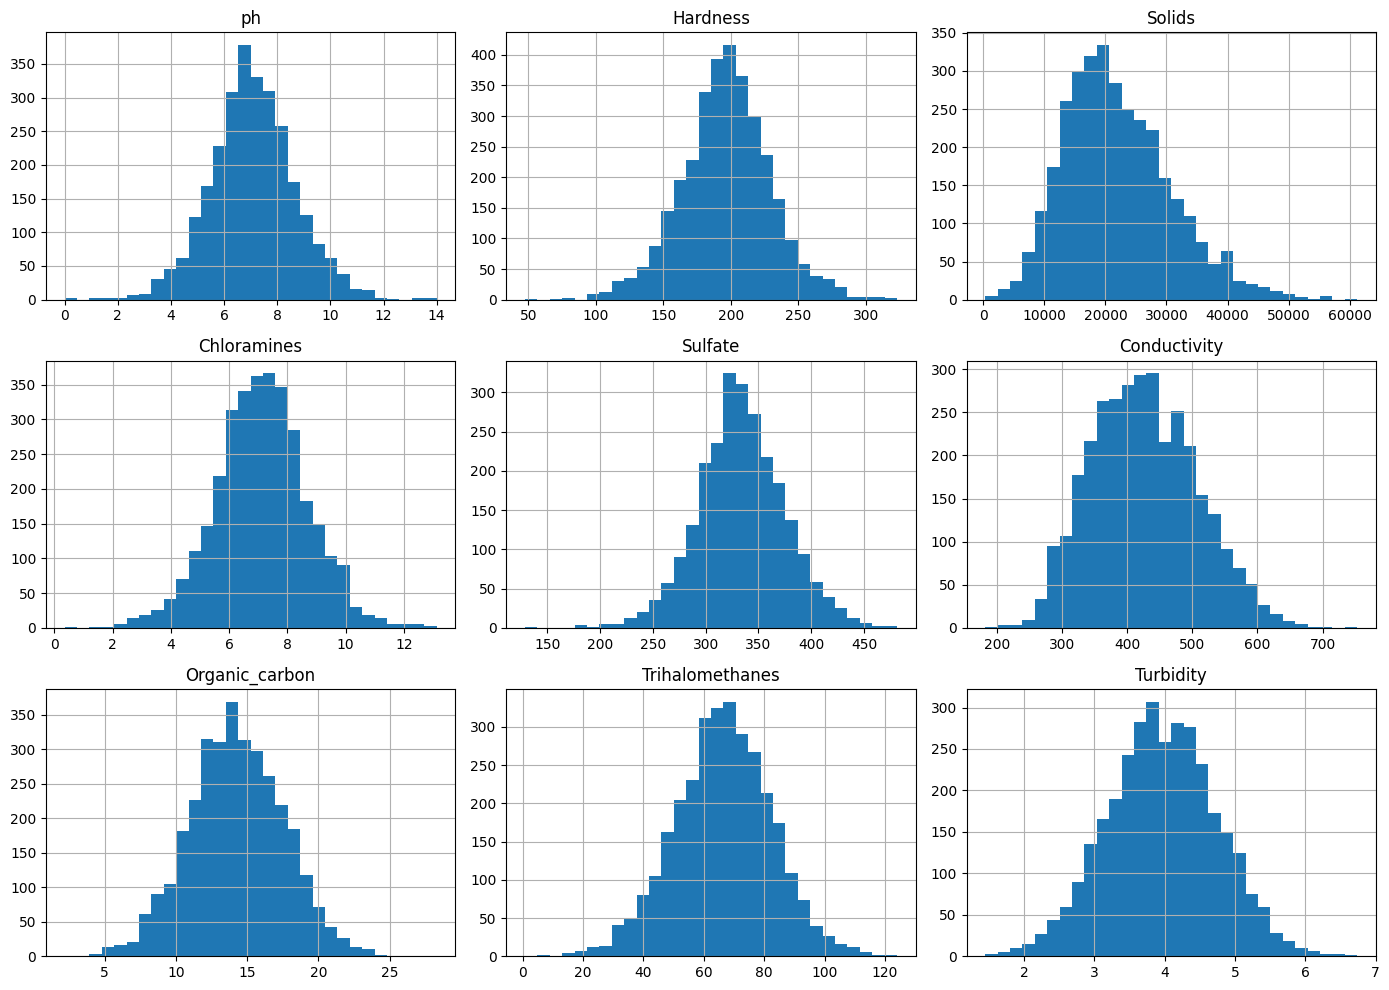

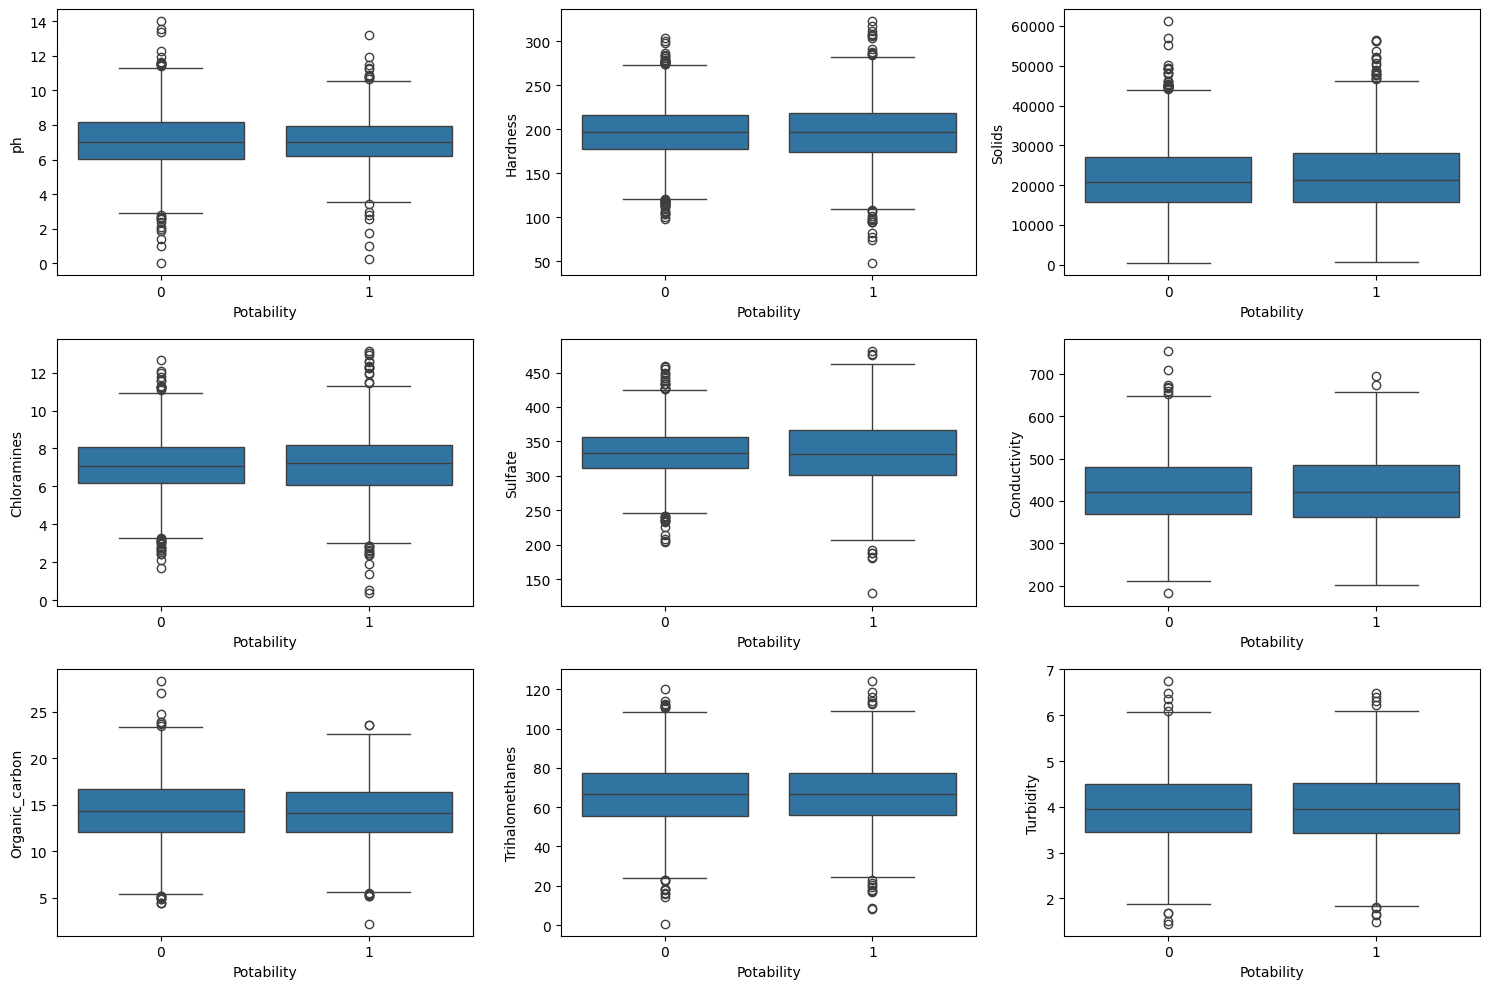

In [28]:
features = df.columns[:-1]


df[features].hist(bins=30, figsize=(14, 10)); plt.tight_layout(); plt.show()


fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, features):
    sns.boxplot(data=df, x="Potability", y=col, ax=ax)
plt.tight_layout(); plt.show()

 Cleaning

In [29]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

In [30]:
X.shape, y.shape


((3276, 9), (3276,))

Train / Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [36]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (2620, 9)
Testing set: (656, 9)


In [37]:
print("Missing values in training data:")
print(X_train.isnull().sum())

print("\nMissing values in testing data:")
print(X_test.isnull().sum())

Missing values in training data:
ph                 387
Hardness             0
Solids               0
Chloramines          0
Sulfate            625
Conductivity         0
Organic_carbon       0
Trihalomethanes    134
Turbidity            0
dtype: int64

Missing values in testing data:
ph                 104
Hardness             0
Solids               0
Chloramines          0
Sulfate            156
Conductivity         0
Organic_carbon       0
Trihalomethanes     28
Turbidity            0
dtype: int64


In [38]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Sulfate,23.840049
ph,14.987790
Trihalomethanes,4.945055
Hardness,0.000000
Chloramines,0.000000
Solids,0.000000
Conductivity,0.000000
Organic_carbon,0.000000
Turbidity,0.000000
Potability,0.000000


Cross-Validation Setup

In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

Logistic Regression

Imputation → Scaling → SMOTE → Logistic Regression

In [40]:
logistic_pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [42]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [43]:
y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.64      0.53      0.58       400
           1       0.42      0.53      0.47       256

    accuracy                           0.53       656
   macro avg       0.53      0.53      0.52       656
weighted avg       0.55      0.53      0.53       656



Random Forest

In [44]:
rf_pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

In [45]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(min_samples_split=5, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

In [46]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.70      0.75      0.72       400
           1       0.56      0.49      0.52       256

    accuracy                           0.65       656
   macro avg       0.63      0.62      0.62       656
weighted avg       0.64      0.65      0.64       656



,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.527439,0.417178,0.531250,0.467354
1,Random Forest,0.647866,0.555556,0.488281,0.519751


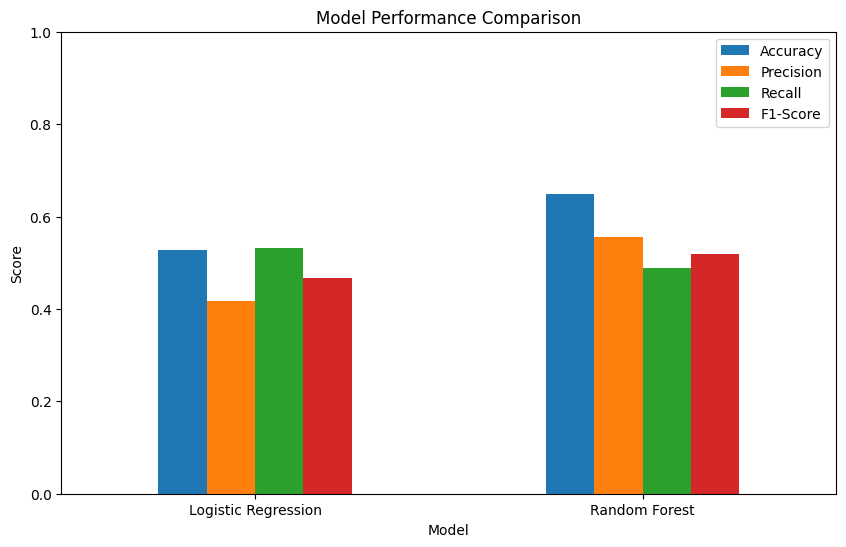

In [49]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    "F1-Score": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)]
})
display(results)

results.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=0); plt.show()

In [50]:
extra_pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("model", ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

In [51]:
extra_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 ExtraTreesClassifier(min_samples_split=5, n_estimators=500,
                                      n_jobs=-1, random_state=42))])

In [52]:
y_pred_extra = extra_pipeline.predict(X_test)
y_prob_extra = extra_pipeline.predict_proba(X_test)[:, 1]

print("Extra Trees")
print(classification_report(y_test, y_pred_extra))

Extra Trees
              precision    recall  f1-score   support

           0       0.68      0.77      0.72       400
           1       0.54      0.43      0.48       256

    accuracy                           0.63       656
   macro avg       0.61      0.60      0.60       656
weighted avg       0.62      0.63      0.62       656



Bagging + Bootstrap

In [53]:
bagging_pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=10,
            min_samples_split=5,
            random_state=42
        ),
        n_estimators=300,
        max_samples=0.8,
        max_features=1.0,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

In [54]:
bagging_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=10,
                                                                    min_samples_split=5,
                                                                    random_state=42),
                                   max_samples=0.8, n_estimators=300, n_jobs=-1,
                                   random_state=42))])

In [55]:
y_pred_bagging = bagging_pipeline.predict(X_test)
y_prob_bagging = bagging_pipeline.predict_proba(X_test)[:, 1]

print("Bagging")
print(classification_report(y_test, y_pred_bagging))

Bagging
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       400
           1       0.55      0.55      0.55       256

    accuracy                           0.65       656
   macro avg       0.63      0.63      0.63       656
weighted avg       0.65      0.65      0.65       656



Voting Classifier


In [56]:
lr_vote = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])


rf_vote = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])


extra_vote = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [57]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", lr_vote),
        ("rf", rf_vote),
        ("extra", extra_vote)
    ],
    voting="soft"
)

In [58]:
voting_pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("model", voting_model)
])

In [59]:
voting_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 VotingClassifier(estimators=[('lr',
                                               Pipeline(steps=[('imputer',
                                                                SimpleImputer(strategy='median')),
                                                               ('scaler',
                                                                StandardScaler()),
                                                               ('model',
                                                                LogisticRegression(max_iter=2000,
                                                                                   random_state=42))])),
                                              ('rf',
                                               Pipeline(steps=[('imputer',
                                                                SimpleImputer(strategy='median')),
                                                               ('model',
                                                                RandomForestClassifier(min_samples_split=5,
                                                                                       n_estimators=300,
                                                                                       n_jobs=-1,
                                                                                       random_state=42))])),
                                              ('extra',
                                               Pipeline(steps=[('imputer',
                                                                SimpleImputer(strategy='median')),
                                                               ('model',
                                                                ExtraTreesClassifier(min_samples_split=5,
                                                                                     n_estimators=300,
                                                                                     n_jobs=-1,
                                                                                     random_state=42))]))],
                                  voting='soft'))])

In [60]:
y_pred_voting = voting_pipeline.predict(X_test)
y_prob_voting = voting_pipeline.predict_proba(X_test)[:, 1]

print("Voting Classifier")
print(classification_report(y_test, y_pred_voting))

Voting Classifier
              precision    recall  f1-score   support

           0       0.69      0.76      0.73       400
           1       0.56      0.47      0.51       256

    accuracy                           0.65       656
   macro avg       0.63      0.62      0.62       656
weighted avg       0.64      0.65      0.64       656



Compare All Models

In [61]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1-Score": f1_score(y_test, y_pred_lr),
        "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-Score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    },
    {
        "Model": "Extra Trees",
        "Accuracy": accuracy_score(y_test, y_pred_extra),
        "Precision": precision_score(y_test, y_pred_extra),
        "Recall": recall_score(y_test, y_pred_extra),
        "F1-Score": f1_score(y_test, y_pred_extra),
        "ROC-AUC": roc_auc_score(y_test, y_prob_extra)
    },
    {
        "Model": "Bagging",
        "Accuracy": accuracy_score(y_test, y_pred_bagging),
        "Precision": precision_score(y_test, y_pred_bagging),
        "Recall": recall_score(y_test, y_pred_bagging),
        "F1-Score": f1_score(y_test, y_pred_bagging),
        "ROC-AUC": roc_auc_score(y_test, y_prob_bagging)
    },
    {
        "Model": "Voting",
        "Accuracy": accuracy_score(y_test, y_pred_voting),
        "Precision": precision_score(y_test, y_pred_voting),
        "Recall": recall_score(y_test, y_pred_voting),
        "F1-Score": f1_score(y_test, y_pred_voting),
        "ROC-AUC": roc_auc_score(y_test, y_prob_voting)
    }
])

results = results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Bagging,0.650915,0.552941,0.550781,0.551859,0.678906
1,Random Forest,0.647866,0.555556,0.488281,0.519751,0.674229
2,Voting,0.649390,0.560185,0.472656,0.512712,0.676650
3,Extra Trees,0.634146,0.539216,0.429688,0.478261,0.672407
4,Logistic Regression,0.527439,0.417178,0.531250,0.467354,0.545908


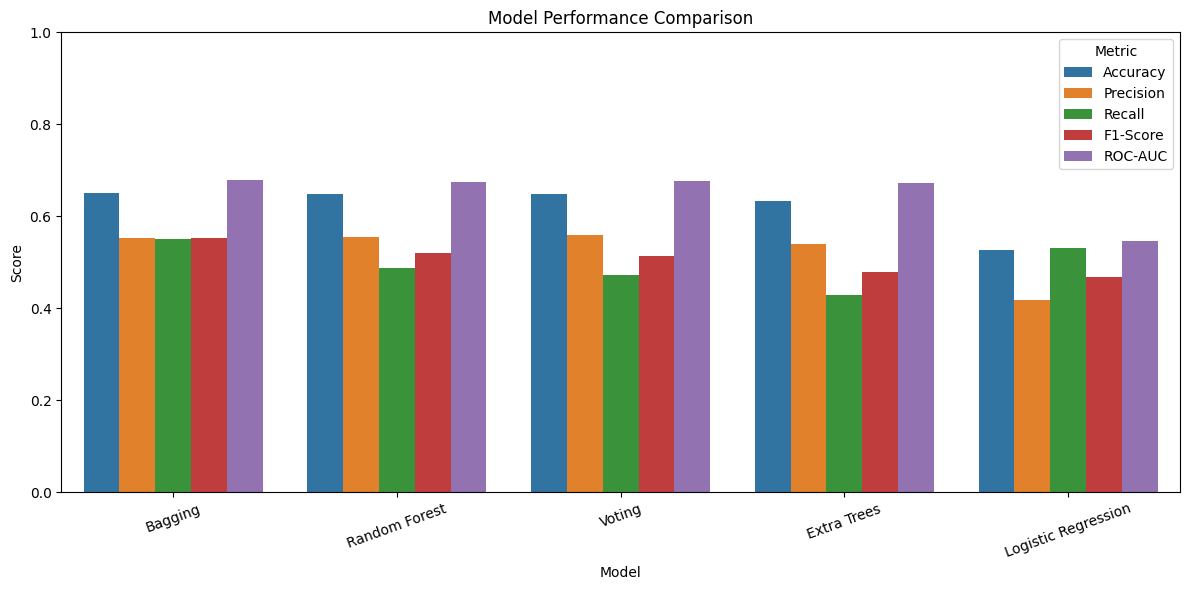

In [62]:
results_melted = results.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

Cross-Validation all Models

In [63]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "Extra Trees": extra_pipeline,
    "Bagging": bagging_pipeline,
    "Voting": voting_pipeline
}

In [64]:
cv_summary = []

for name, model in models.items():

    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_summary.append({
        "Model": name,
        "CV Accuracy": cv_result["test_accuracy"].mean(),
        "CV Precision": cv_result["test_precision"].mean(),
        "CV Recall": cv_result["test_recall"].mean(),
        "CV F1": cv_result["test_f1"].mean(),
        "CV ROC-AUC": cv_result["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_summary)

cv_results = cv_results.sort_values(
    by="CV F1",
    ascending=False
).reset_index(drop=True)

cv_results

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Bagging,0.635115,0.531433,0.555739,0.541988,0.676128
1,Random Forest,0.649618,0.554447,0.522477,0.537076,0.682675
2,Voting,0.651145,0.558205,0.506801,0.530183,0.682958
3,Extra Trees,0.651908,0.562205,0.491143,0.522589,0.691241
4,Logistic Regression,0.487023,0.371501,0.455017,0.408845,0.474181


Random Forest Hyperparameter Tuning

In [67]:
rf_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

In [68]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        RandomForestClassifier(min_samples_split=5,
                                                               n_estimators=500,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [300, 500]},
             scoring='f1', verbose=1)

Best Parameters

In [69]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV F1-Score:")
print(rf_grid.best_score_)

Best Parameters:
{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Best CV F1-Score:
0.5524272321639068


Tuned Random Forest Evaluation

In [70]:
best_rf = rf_grid.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73       400
           1       0.57      0.52      0.54       256

    accuracy                           0.66       656
   macro avg       0.64      0.63      0.64       656
weighted avg       0.66      0.66      0.66       656



Tuned Model Metrics

In [71]:
tuned_rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_best_rf),
        roc_auc_score(y_test, y_prob_best_rf)
    ]
})

tuned_rf_results

,Metric,Score
0,Accuracy,0.660061
1,Precision,0.570815
2,Recall,0.519531
3,F1-Score,0.543967
4,ROC-AUC,0.678574


In [72]:
cv_probabilities = cross_val_predict(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

Find Best Threshold

In [73]:
thresholds = np.arange(0.20, 0.81, 0.01)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        cv_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_train,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_train,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_train,
            y_pred_threshold
        ),
        "F1-Score": f1_score(
            y_train,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best Threshold:", best_threshold)
print("CV F1-Score:", best_threshold_row["F1-Score"])

Best Threshold: 0.36000000000000015
CV F1-Score: 0.5877788554801164


In [ ]:
y_pred_threshold_test = (
    y_prob_best_rf >= best_threshold
).astype(int)

print(classification_report(
    y_test,
    y_pred_threshold_test
))

In [76]:
y_pred_threshold_test = (y_prob_best_rf >= best_threshold).astype(int)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred_threshold_test),
        precision_score(y_test, y_pred_threshold_test),
        recall_score(y_test, y_pred_threshold_test),
        f1_score(y_test, y_pred_threshold_test),
        roc_auc_score(y_test, y_prob_best_rf)
    ]
})

final_results

,Metric,Score
0,Accuracy,0.513720
1,Precision,0.438596
2,Recall,0.878906
3,F1-Score,0.585176
4,ROC-AUC,0.678574


Confusion Matrix

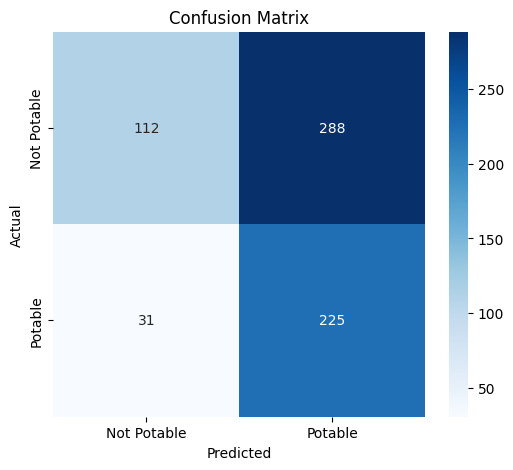

In [77]:
cm = confusion_matrix(
    y_test,
    y_pred_threshold_test
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Potable", "Potable"],
    yticklabels=["Not Potable", "Potable"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC Curve

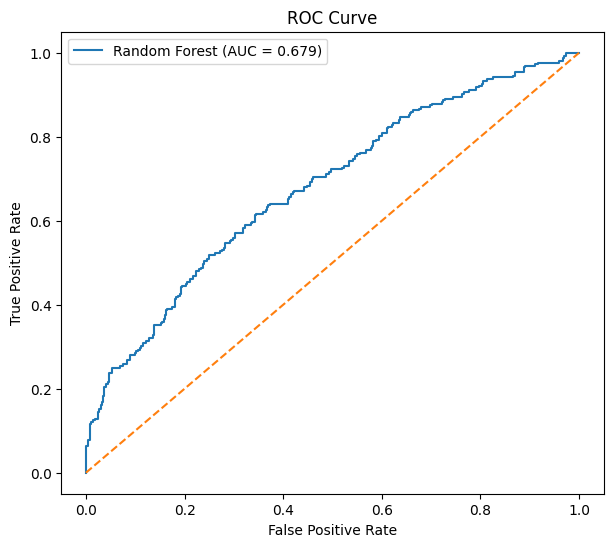

In [78]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_best_rf
)

auc_score = roc_auc_score(
    y_test,
    y_prob_best_rf
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [79]:
rf_final_model = best_rf.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,ph,0.144578
4,Sulfate,0.128446
2,Solids,0.122688
1,Hardness,0.115874
3,Chloramines,0.114787
8,Turbidity,0.095611
6,Organic_carbon,0.094372
5,Conductivity,0.093852
7,Trihalomethanes,0.089792


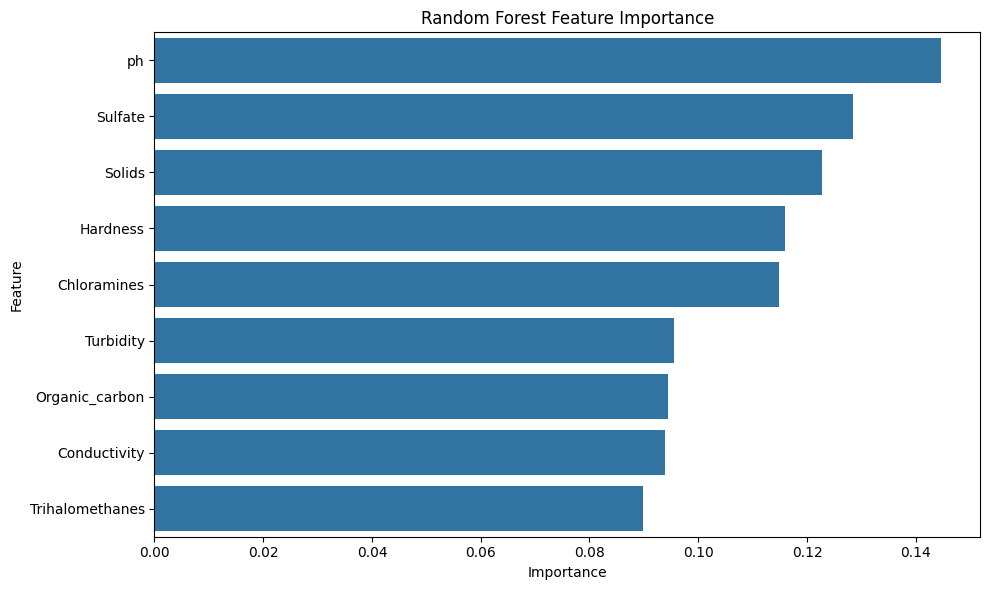

In [80]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

Prediction on a Sample

In [81]:
sample = pd.DataFrame([{
    "ph": 7.0,
    "Hardness": 190.0,
    "Solids": 20000.0,
    "Chloramines": 7.0,
    "Sulfate": 330.0,
    "Conductivity": 420.0,
    "Organic_carbon": 14.0,
    "Trihalomethanes": 66.0,
    "Turbidity": 4.0
}])

In [83]:
probability = best_rf.predict_proba(sample)
prediction = int(probability[0][1] >= best_threshold)

In [84]:
print("Prediction:", prediction)
print("Probability:", probability[0])

Prediction: 1
Probability: [0.5284819 0.4715181]


In [85]:
if prediction == 1:
    print("Water is predicted to be Potable")
else:
    print("Water is predicted to be Not Potable")

Water is predicted to be Potable


Save Model

In [86]:
import joblib
from google.colab import files

joblib.dump({"model": best_rf, "threshold": float(best_threshold)}, "water_potability_model.pkl")

files.download("water_potability_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>